In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# K_means_clustering

In [24]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [74]:
X, y = make_blobs(n_samples=500, cluster_std=4, centers=3,random_state=42)

In [75]:
df=pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [76]:
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [77]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

df_scaled=scaler.fit_transform(df)

In [78]:
inertia =[]
k_range=range(1,11)                     # for 10 points in the graph !!

for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

In [79]:
inertia

[999.9999999999994,
 528.8064432605643,
 294.4377068678185,
 250.4552469653445,
 216.88110656982604,
 185.27440675195913,
 156.70879996290438,
 135.62603453115264,
 129.1039634823981,
 119.94101297104991]

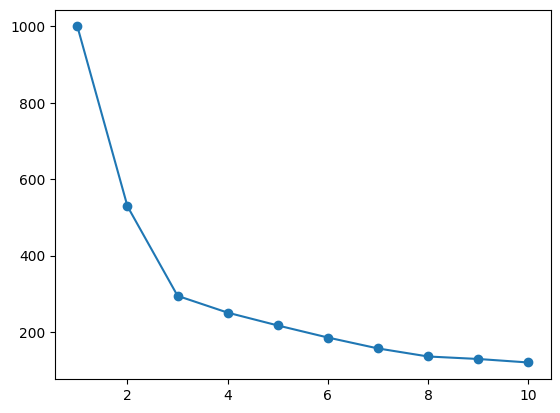

In [80]:
plt.plot(k_range,inertia,marker='o')


In [81]:
k_means_final=KMeans(n_clusters=3,random_state=42)
k_means_final.fit(df_scaled)

KMeans(n_clusters=3, random_state=42)

In [82]:
y_predict=k_means_final.predict(df_scaled)
y_predict

array([1, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2, 1, 1, 2, 2, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 2, 2, 2,
       0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 2,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 0, 0, 2, 0, 1, 1, 1, 0,
       2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 2,
       2, 1, 2, 1, 0, 0, 0, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       2, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 1,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 2, 0, 0, 0,

In [83]:
df['cluster']=y_predict
df.head()

,Feature_1,Feature_2,cluster
0,-2.282534,-9.692815,1
1,-6.147668,1.755990,2
2,13.399091,-1.260023,0
3,-4.077630,3.160226,2
4,9.444735,0.340868,0


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

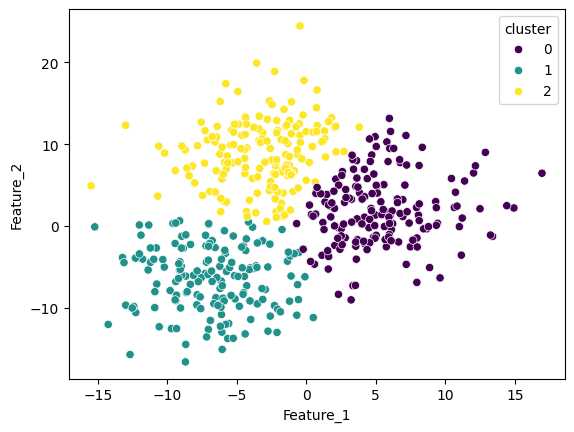

In [84]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='viridis')

# DB SCAN [Density-Based Spatial Clustering of Applications with Noise]

In [103]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [104]:
from sklearn.cluster import KMeans, DBSCAN

In [105]:
df_new = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df_new.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [106]:
scaler = StandardScaler()
X_scaled=scaler.fit_transform(df_new)

In [107]:
kmeans_model = KMeans(n_clusters=2, random_state=42)
kmeans_model.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

In [108]:
y_predict = kmeans_model.predict(X_scaled)
y_predict

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,

In [109]:
df_new['kmeans_cluster'] = y_predict

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

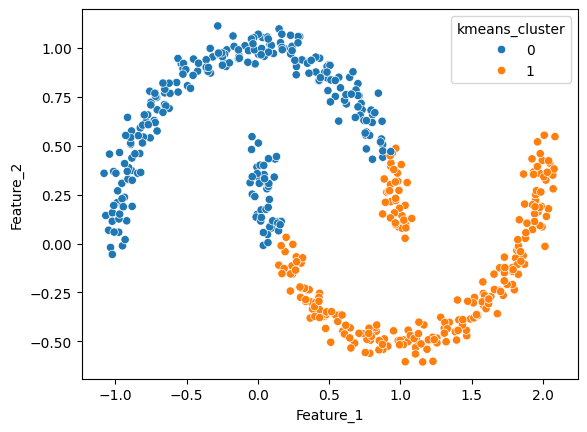

In [110]:
sns.scatterplot(x=df_new['Feature_1'], y=df_new['Feature_2'], hue=df_new['kmeans_cluster'] ,palette='tab10')

In [112]:
dbscan_model = DBSCAN(eps=0.3, min_samples=5)
dbscan_model.fit(X_scaled)

DBSCAN(eps=0.3)

In [113]:
y_predict=dbscan_model.fit_predict(X_scaled)
y_predict

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [114]:
df_new['DBSCAN_cluster'] = y_predict

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

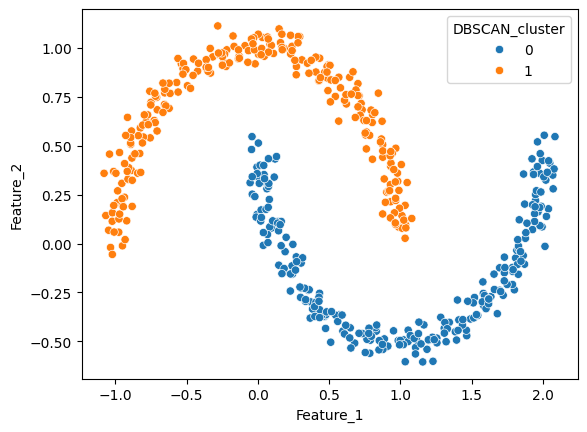

In [115]:
sns.scatterplot(x=df_new['Feature_1'], y=df_new['Feature_2'], hue=df_new['DBSCAN_cluster'] ,palette='tab10')
